M (analytically) = [-5.29274599 -3.93827512 -4.02017067 -3.9309573  -3.64648454 -3.32727564
 -3.4560996  -3.03370895 -3.22673334 -2.84816768] ± [0.22843951 0.14495582 0.12195694 0.19589562 0.16500961 0.31037688
 0.09419541 0.1525707  0.27767251 0.19159227]



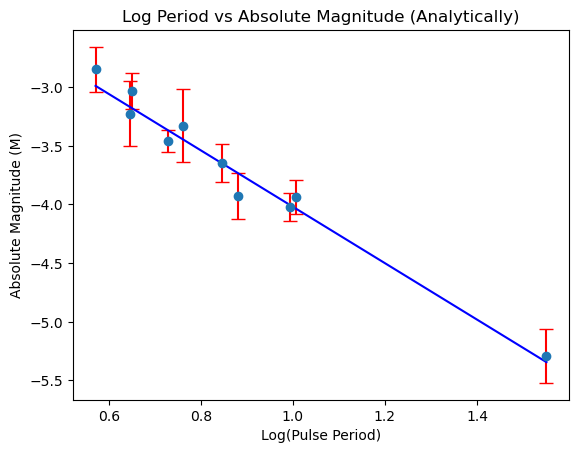

alpha (analytically) = -2.4053156932326187 ± 0.16700151765413634
beta (analytically) = -1.6139061219404138 ± 0.14542549561015336

chi squared for the fit:  4.025315549301818
Reduced chi squared for the fit:  0.5031644436627273

Expected chi squared for the fit: 8 ± 4.0

M (numerically) = [-5.27038218 -3.9292478  -4.01466596 -3.91320793 -3.63888409 -3.28291522
 -3.4523415  -3.02464656 -3.19247286 -2.83492141] ± [0.3141659  0.20188811 0.16450573 0.27640017 0.21131983 0.43234009
 0.12999186 0.20692264 0.38572499 0.25730429]



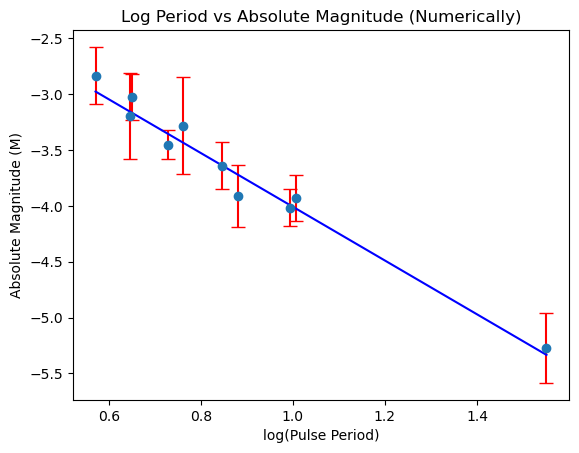

alpha (numerically) = -2.4061741460738855 ± 0.1692218094578397
beta (numerically) = -1.6019647827410781 ± 0.14720962940387403

chi squared for the fit:  2.203175873132959
Reduced chi squared for the fit:  0.2753969841416199

Expected chi squared for the fit: 8 ± 4.0



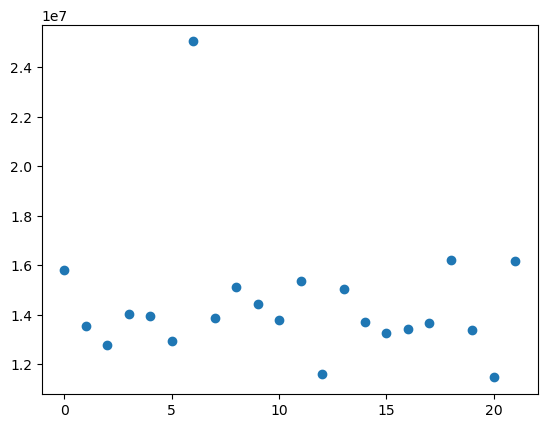


Data point 7 is an outlier, now removing this value


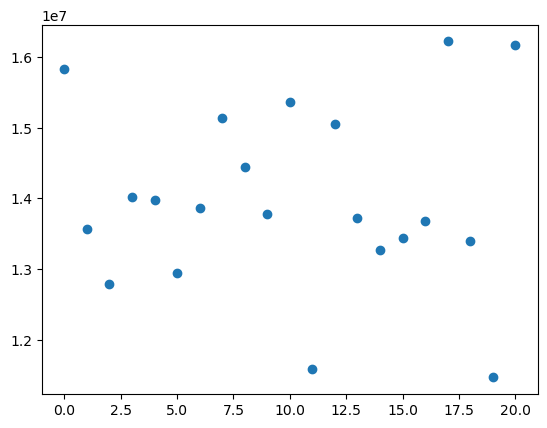


Mean distance (derived analytically)=  13986936.084030379 ± [748929.2650442129] pc
Mean distance (derived numerically)=  13918441.898809377 ± 275030.95815490343 pc

Hubble constant (derived analytically) =  82.3625698350977 ± [4.41009657] km/s/Mpc
Hubble constant (derived numerically) =  83.46232857311118 ± 1.6856864195882209 km/s/Mpc



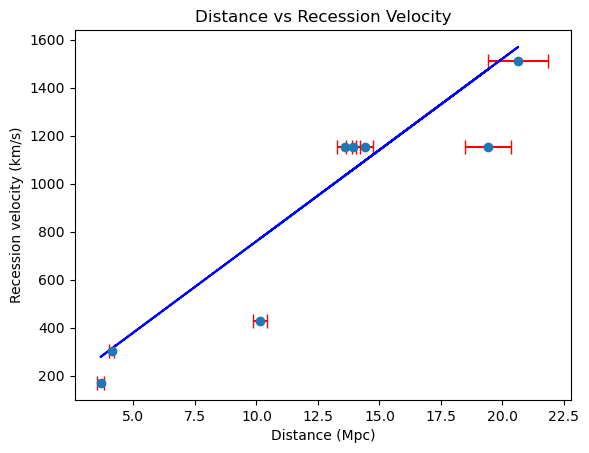

Final value for Hubbles constant using other galaxies data = [76.044378] ± [5.87921893]

chi squared for the fit:  441.1021219029454
Reduced chi squared for the fit:  63.01458884327791

Expected chi squared for the fit: 7 ± 3.7416573867739413



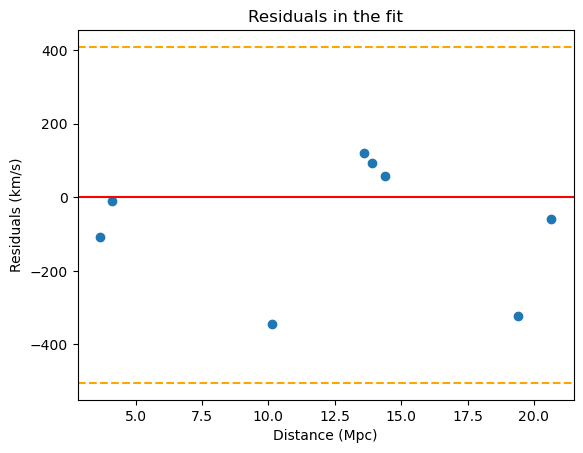

No outliers found in the residuals.



In [1]:
import math
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

############################################### STEP 1 ########################################################

parallax, para_error, period, m, A, A_error = np.loadtxt("MW_Cepheids.dat", unpack=True, dtype=float, usecols=(1, 2, 3, 4, 5, 6))

# Create lists for distance and distance uncertainty
distance = []
distance_unc = []

for i in range(len(parallax)):
    mean_parallax = parallax[i]
    std_parallax = para_error[i]
    draw_parallax = np.random.normal(mean_parallax, std_parallax, 100000)
    
    distance.append(1000 / draw_parallax)
    distance_unc.append((1000 / (draw_parallax)**2) * std_parallax)

# Convert lists to arrays
distance = np.array(distance)
distance_unc = np.array(distance_unc)

# Create list for mean distance
mean_distance = []

# Calculate mean distance for each Cepheid
for i in range(len(parallax)):
    mean_distance.append(np.mean(distance[i])) 

mean_distance = np.array(mean_distance)  


mean_distance_unc = []

# Calculate mean distance_unc for each Cepheid
for i in range(len(parallax)):
    mean_distance_unc.append(np.mean(distance_unc[i])) 

mean_distance_unc = np.array(mean_distance_unc) 

# Calculate M using the mean distance
M = m - (5 * np.log10(mean_distance)) + 5 - A

# Uncertainty M analytically    
M_unc = np.sqrt(((-5/(mean_distance * np.log(10))) * (mean_distance_unc))**2 + ((A_error**2)))

# Print results
print("M (analytically) =", M, "±", M_unc)    
print()

# Calculating log of pulse period
logP = np.log10(period)


# Using gradient and y-intercept to find alpha and beta (analytically)

# Define the linear function for curve fitting
def linear_func(x1, m1, b1):
    return m1 * x1 + b1

# Use curve_fit to fit the linear function to the data
params1, covariance1 = curve_fit(linear_func, logP, M, sigma=M_unc)

# Extract the gradient and y-intercept
gradient1, intercept1 = params1

alpha1 = gradient1
beta1 = intercept1

# Calculate the uncertainties in alpha and beta
alpha1_uncertainty = np.sqrt(covariance1[0, 0])  # Uncertainty in alpha
beta1_uncertainty = np.sqrt(covariance1[1, 1])  # Uncertainty in beta

# Calculate the best fit line
best_fit_line1 = linear_func(logP, gradient1, intercept1)

# Plotting logP against M ANALYTICALLY
plt.errorbar(logP, M, yerr=M_unc, ecolor="red", capsize=5, fmt="o")
plt.plot(logP, best_fit_line1, color="blue", label="Line of Best Fit")
plt.title('Log Period vs Absolute Magnitude (Analytically)')
plt.xlabel('Log(Pulse Period)')
plt.ylabel('Absolute Magnitude (M)')
plt.show()

print("alpha (analytically) =", alpha1, "±", alpha1_uncertainty)  # Print alpha with uncertainty
print("beta (analytically) =", beta1, "±", beta1_uncertainty)  # Print beta with uncertainty
print()

#Chi squared test for the fit
chi_sq1 = 0

for i in range (len(M)):
    chi_sq1 = chi_sq1 + (((M[i] - best_fit_line1[i])/M_unc[i]))**2
    
print ("chi squared for the fit: ",chi_sq1)

dof1= len(M) - 2

chi_sq_reduced1 = chi_sq1/dof1

print ("Reduced chi squared for the fit: ",chi_sq_reduced1)
print()
print ("Expected chi squared for the fit:",dof1, "±", np.sqrt(2*dof1))
print()
                       
# Uncertainty M numerically
M_mean = np.zeros(len(m))
M_std = np.zeros(len(m))

for i in range(len(m)):
    mean_distance = distance[i]
    std_distance = distance_unc[i]
    draw_distance = np.random.normal(mean_distance, std_distance, 100000)
    
    mean_A = A[i]
    std_A = A_error[i]
    draw_A = np.random.normal(mean_A, std_A, 100000)
    
    M_value = (m[i] - 5 * (np.log10(draw_distance)) + 5 - draw_A)
    M_mean[i] = np.mean(M_value)
    M_std[i] = np.std(M_value)

# Print results
print("M (numerically) =", M_mean, "±", M_std)
print()


# Using gradient and y-intercept to find alpha and beta (numerically)

# Define the linear function for curve fitting
def linear_func(x2, m2, b2):
    return m2 * x2 + b2

# Use curve_fit to fit the linear function to the data
params2, covariance2 = curve_fit(linear_func, logP, M_mean, sigma=M_std)

# Extract the gradient and y-intercept
gradient2, intercept2 = params2

alpha2 = gradient2
beta2 = intercept2

# Calculate the uncertainties in alpha and beta
alpha2_uncertainty = np.sqrt(covariance2[0, 0])  # Uncertainty in alpha
beta2_uncertainty = np.sqrt(covariance2[1, 1])  # Uncertainty in beta


# Calculate the best fit line
best_fit_line2 = linear_func(logP, gradient2, intercept2)


# Plotting logP against M NUMERICALLY
plt.errorbar(logP, M_mean, yerr=M_std, ecolor="red", capsize=5, fmt="o")
plt.plot(logP, best_fit_line2, color="blue", label="Line of Best Fit")
plt.xlabel('log(Pulse Period)')
plt.ylabel('Absolute Magnitude (M)')
plt.title('Log Period vs Absolute Magnitude (Numerically)')
plt.show()

print("alpha (numerically) =", alpha2, "±", alpha2_uncertainty)  # Print alpha with uncertainty
print("beta (numerically) =", beta2, "±", beta2_uncertainty)  # Print beta with uncertainty
print()

#Chi squared test for the fit
chi_sq2 = 0

for i in range (len(M_mean)):
    chi_sq2 = chi_sq2 + (((M_mean[i] - best_fit_line2[i])/M_std[i]))**2
    
print ("chi squared for the fit: ",chi_sq2)

dof2= len(M_mean) - 2

chi_sq_reduced2 = chi_sq2/dof2

print ("Reduced chi squared for the fit: ",chi_sq_reduced2)
print()
print ("Expected chi squared for the fit:",dof2, "±", np.sqrt(2*dof2))
print()

############################################### STEP 2 #######################################################

cepheids_logP, cepheids_m = np.loadtxt("ngc4527_cepheids.dat", unpack=True, dtype=float, usecols=(1, 2))

#Using alpha and beta from analytical values
ceph_distance1 = []
for i in range (len(cepheids_m)):
    ceph_distance1.append(10**((alpha1*cepheids_logP[i] + beta1 + 0.0682 - 5 -cepheids_m[i])/(-5)))

#plot distances to identify and remove outliers
plt.errorbar(list(range(len(ceph_distance1))), ceph_distance1, ecolor="red", capsize=5, fmt="o")
plt.show()

print()
print("Data point 7 is an outlier, now removing this value")
removed_value = ceph_distance1.pop(6)

#plot distances again to show outlier has been removed
plt.errorbar(list(range(len(ceph_distance1))), ceph_distance1, ecolor="red", capsize=5, fmt="o")
plt.show()
print()

mean_ceph_distance1 = np.mean(ceph_distance1)

#Using error propogation for uncertainty in distance
ceph_distance_unc = []

# Calculate partial derivatives
d_alpha = (mean_ceph_distance1 /-5) * (cepheids_logP[i])
d_beta = (mean_ceph_distance1 /-5)

ceph_distance_unc.append(np.sqrt((d_alpha * alpha1_uncertainty)**2 + (d_beta * beta1_uncertainty)**2))

print("Mean distance (derived analytically)= ", (mean_ceph_distance1), "±", (ceph_distance_unc), "pc")

#Using alpha and beta from numerical values
ceph_distance2 = []
for i in range (len(cepheids_m)):
    ceph_distance2.append(10**((alpha2*cepheids_logP[i] + beta2 + 0.0682 - 5 -cepheids_m[i])/(-5)))

removed_value = ceph_distance2.pop(6)

# Calculating mean, standard deviation, standard error of distance
mean_ceph_distance2 = np.mean(ceph_distance2)
std_ceph_distance = np.std(ceph_distance2)
stnderror = std_ceph_distance/(np.sqrt(len(ceph_distance2)))

print("Mean distance (derived numerically)= ", (mean_ceph_distance2), "±", (stnderror), "pc")
print()

############################################### STEP 3 #######################################################

# Calculating Hubble constant with uncertainty analytically

v_rec = 1152

#changing to arrays
mean_ceph_distance1 = np.array(mean_ceph_distance1) 
ceph_distance_unc = np.array(ceph_distance_unc)

H1 = v_rec / (mean_ceph_distance1/1000000)
H1_unc = np.sqrt(((-1152/((mean_ceph_distance1/1000000)**2))*(ceph_distance_unc/1000000))**2)
print ("Hubble constant (derived analytically) = ",H1, "±", (H1_unc), "km/s/Mpc")

# Calculating Hubble constant with uncertainty numerically

ceph_distance2=np.array(ceph_distance2)
H2 = v_rec / (ceph_distance2/1000000)

# Calculating mean, standard deviation, standard error of Hubble constant
mean_Hubble = np.mean(H2)
std_Hubble = np.std(H2)
H_stderror = std_Hubble/(np.sqrt(len(H2)))
print ("Hubble constant (derived numerically) = ",mean_Hubble, "±", H_stderror, "km/s/Mpc")
print()

#######################Using data from other galaxies to get a more accurate value of Hubble constant

v_rec_gal, distance_gal, distance_gal_error = np.loadtxt("other_galaxies.dat", unpack=True, dtype=float, usecols=(1, 2, 3))

#Adding data for NGC4527 to the set
v_rec_gal=np.append(v_rec_gal, 1152)
distance_gal=np.append(distance_gal,mean_ceph_distance2/1000000)
distance_gal_error=np.append(distance_gal_error,stnderror/1000000)


# Define the linear function for curve fitting
def linear_func(x3, m3):
    return m3 * x3 

# Use curve_fit to fit the linear function to the data
params3, covariance3 = curve_fit(linear_func, v_rec_gal, distance_gal, sigma=distance_gal_error)

# Extract the gradient and intercept 
gradient3 = params3  
Hubble_gal = 1/gradient3

# Calculate the standard deviation in Hubble
Hubble_gal_unc = (1/gradient3**2)*np.sqrt(covariance3[0, 0])

# Calculate the best fit line
best_fit_line3 = linear_func(distance_gal, Hubble_gal)

# Plotting distance_gal against v_rec_gal
plt.errorbar(distance_gal, v_rec_gal, xerr=distance_gal_error, ecolor="red", fmt="o", capsize=5, label="Data points with error")
plt.plot(distance_gal, best_fit_line3, color="blue", label="Line of Best Fit")
plt.xlabel('Distance (Mpc)')  
plt.ylabel('Recession velocity (km/s)')  
plt.title('Distance vs Recession Velocity')
plt.show()

print("Final value for Hubbles constant using other galaxies data =",  Hubble_gal, "±", Hubble_gal_unc)
print()


#Chi squared test for the fit

best_fit_line4 = linear_func(v_rec_gal, gradient3)

chi_sq3 = 0

for i in range (len(distance_gal)):
    chi_sq3 = chi_sq3 + (((distance_gal[i] - best_fit_line4[i])/distance_gal_error[i]))**2
    
print ("chi squared for the fit: ",chi_sq3)

dof3= len(distance_gal) - 1

chi_sq_reduced3 = chi_sq3/dof3

print ("Reduced chi squared for the fit: ",chi_sq_reduced3)
print()
print ("Expected chi squared for the fit:",dof3, "±", np.sqrt(2*dof3))
print()


# Calculate residuals (difference between observed and predicted values)
residuals = v_rec_gal - best_fit_line3

# Calculate IQR to identify outliers
Q1 = np.percentile(residuals, 25)
Q3 = np.percentile(residuals, 75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = residuals[(residuals < lower_bound) | (residuals > upper_bound)]
outlier_indices = np.where((residuals < lower_bound) | (residuals > upper_bound))[0]

# Plot residuals to identify outliers
plt.scatter(distance_gal, residuals, label='Residuals')
plt.axhline(0, color='red', linestyle='-')
plt.axhline(lower_bound, color='orange', linestyle='--', label='Lower Bound')
plt.axhline(upper_bound, color='orange', linestyle='--', label='Upper Bound')
plt.xlabel('Distance (Mpc)')
plt.ylabel('Residuals (km/s)')
plt.title('Residuals in the fit')
plt.show()

# Check if there are any outliers and print them
if len(outliers) > 0:
    print("Outliers in the residuals:", outliers)
    print("Indices of outliers:", outlier_indices)
else:
    print("No outliers found in the residuals.")
print()
   



